# Data processing and Features Engineering

#### 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
from typing import Optional, Tuple
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

##### 2. Load and Explore the Dataset

In [2]:
# Selected match_id for analysis
match_id = "DFL-MAT-J03YLO"

In [3]:
# import from csv
pos = pd.read_csv(f'tracking_data_{match_id}.csv')

In [4]:
# define home and away team codes
home_team = pos['home_team_code'][0]
print(f"home Team is: {home_team}")

away_team = pos['away_team_code'][0]
print(f"away Team is: {away_team}")

home Team is: WOB
away Team is: SVD


In [6]:
pos.head(23)

,match_id,match_title,team_code,home_team_code,away_team_code,player_name,frame,game_section,x_position,y_position,z_position,speed,ball_status,ball_possession
0,DFL-MAT-J03YLO,VfL Wolfsburg:SV Darmstadt 98,SVD,WOB,SVD,A. Brunst,1,firstHalf,-43.86,0.11,NaN,0.00,NaN,NaN
1,DFL-MAT-J03YLO,VfL Wolfsburg:SV Darmstadt 98,SVD,WOB,SVD,C. Klarer,1,firstHalf,-16.72,3.28,NaN,0.00,NaN,NaN
2,DFL-MAT-J03YLO,VfL Wolfsburg:SV Darmstadt 98,SVD,WOB,SVD,C. Zimmermann,1,firstHalf,-16.41,14.04,NaN,0.00,NaN,NaN
3,DFL-MAT-J03YLO,VfL Wolfsburg:SV Darmstadt 98,SVD,WOB,SVD,M. Maglica,1,firstHalf,-16.37,-4.52,NaN,0.00,NaN,NaN
4,DFL-MAT-J03YLO,VfL Wolfsburg:SV Darmstadt 98,SVD,WOB,SVD,E. Karic,1,firstHalf,-12.43,22.08,NaN,0.00,NaN,NaN
5,DFL-MAT-J03YLO,VfL Wolfsburg:SV Darmstadt 98,SVD,WOB,SVD,A. Müller,1,firstHalf,-11.47,8.22,NaN,0.00,NaN,NaN
6,DFL-MAT-J03YLO,VfL Wolfsburg:SV Darmstadt 98,SVD,WOB,SVD,F. Nürnberger,1,firstHalf,-10.15,-15.34,NaN,0.00,NaN,NaN
7,DFL-MAT-J03YLO,VfL Wolfsburg:SV Darmstadt 98,SVD,WOB,SVD,J. Justvan,1,firstHalf,-8.81,-2.60,NaN,0.00,NaN,NaN
8,DFL-MAT-J03YLO,VfL Wolfsburg:SV Darmstadt 98,SVD,WOB,SVD,M. Mehlem,1,firstHalf,-7.81,6.07,NaN,0.00,NaN,NaN
9,DFL-MAT-J03YLO,VfL Wolfsburg:SV Darmstadt 98,SVD,WOB,SVD,O. Vilhelmsson,1,firstHalf,-1.41,-9.14,NaN,0.00,NaN,NaN


# Soccer Pitch
#### Draw a standard football pitch centered at (0,0) in meters.

In [5]:
# Function to draw a soccer pitch
def draw_soccer_pitch(
    ax=None,
    figsize=(12, 8),
    pitch_length_m: float = 105.0,
    pitch_width_m: float = 68.0,
    scale: float = 1.0,           # switch scale: 1 (raw) / 15 (after normalization)
    line_color: str = "black",
    line_width: float = 1.0,
):
    # Create axes if not provided
    if ax is None:
        _, ax = plt.subplots(figsize=figsize)

    # Marking dimensions (meters)
    CENTER_CIRCLE_R = 9.15
    SPOT_R = 0.30
    PENALTY_SPOT_DIST = 11.0
    PA_DEPTH, PA_WIDTH = 16.5, 40.32
    GA_DEPTH, GA_WIDTH = 5.5, 18.32
    MARGIN = 1.0

    # Pitch extents (centered)
    L = pitch_length_m / scale
    W = pitch_width_m / scale
    half_L, half_W = L / 2.0, W / 2.0
    cc_r = CENTER_CIRCLE_R / scale
    spot_r = SPOT_R / scale
    pa_d, pa_w = PA_DEPTH / scale, PA_WIDTH / scale
    ga_d, ga_w = GA_DEPTH / scale, GA_WIDTH / scale
    pen_spot = PENALTY_SPOT_DIST / scale
    margin = MARGIN / scale

    # Field outline
    ax.add_patch(plt.Rectangle((-half_L, -half_W), L, W, fill=False,
                               color=line_color, linewidth=line_width))
    # Halfway line & center marks
    ax.plot([0, 0], [-half_W, half_W], color=line_color, linewidth=line_width)
    ax.add_patch(plt.Circle((0, 0), cc_r, fill=False, color=line_color, linewidth=line_width))
    ax.add_patch(plt.Circle((0, 0), spot_r, color=line_color))

    # Penalty areas
    ax.add_patch(plt.Rectangle((-half_L, -pa_w/2), pa_d, pa_w, fill=False,
                               color=line_color, linewidth=line_width))
    ax.add_patch(plt.Rectangle((half_L - pa_d, -pa_w/2), pa_d, pa_w, fill=False,
                               color=line_color, linewidth=line_width))

    # Goal areas
    ax.add_patch(plt.Rectangle((-half_L, -ga_w/2), ga_d, ga_w, fill=False,
                               color=line_color, linewidth=line_width))
    ax.add_patch(plt.Rectangle((half_L - ga_d, -ga_w/2), ga_d, ga_w, fill=False,
                               color=line_color, linewidth=line_width))

    # Penalty spots
    ax.add_patch(plt.Circle((-half_L + pen_spot, 0), spot_r, color=line_color))
    ax.add_patch(plt.Circle((half_L - pen_spot, 0), spot_r, color=line_color))

    # Axes
    ax.set_xlim(-half_L - margin, half_L + margin)
    ax.set_ylim(-half_W - margin, half_W + margin)
    ax.set_aspect("equal")
    ax.axis("off")
    return ax

# Data Cleaning & preprocessing

#### 1. Remove all rows where the ball is static

In [9]:
# Find frames where ball_status == False
frames_to_drop = pos.loc[pos['ball_status'] == False, 'frame'].unique()

# Drop all rows where frame is in this list
pos = pos[~pos['frame'].isin(frames_to_drop)]

# Display
pos



,match_id,match_title,team_code,home_team_code,away_team_code,player_name,frame,game_section,x_position,y_position,z_position,speed,ball_status,ball_possession
0,DFL-MAT-J03YLO,VfL Wolfsburg:SV Darmstadt 98,SVD,WOB,SVD,A. Brunst,1,firstHalf,-43.86,0.11,NaN,0.00,NaN,NaN
1,DFL-MAT-J03YLO,VfL Wolfsburg:SV Darmstadt 98,SVD,WOB,SVD,C. Klarer,1,firstHalf,-16.72,3.28,NaN,0.00,NaN,NaN
2,DFL-MAT-J03YLO,VfL Wolfsburg:SV Darmstadt 98,SVD,WOB,SVD,C. Zimmermann,1,firstHalf,-16.41,14.04,NaN,0.00,NaN,NaN
3,DFL-MAT-J03YLO,VfL Wolfsburg:SV Darmstadt 98,SVD,WOB,SVD,M. Maglica,1,firstHalf,-16.37,-4.52,NaN,0.00,NaN,NaN
4,DFL-MAT-J03YLO,VfL Wolfsburg:SV Darmstadt 98,SVD,WOB,SVD,E. Karic,1,firstHalf,-12.43,22.08,NaN,0.00,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3377499,DFL-MAT-J03YLO,VfL Wolfsburg:SV Darmstadt 98,WOB,WOB,SVD,J. Kaminski,163480,secondHalf,-38.66,0.16,NaN,1.15,NaN,NaN
3377500,DFL-MAT-J03YLO,VfL Wolfsburg:SV Darmstadt 98,WOB,WOB,SVD,V. Cerny,163480,secondHalf,-36.21,18.34,NaN,3.60,NaN,NaN
3377501,DFL-MAT-J03YLO,VfL Wolfsburg:SV Darmstadt 98,WOB,WOB,SVD,Tiago Tomas,163480,secondHalf,-22.60,1.96,NaN,3.76,NaN,NaN
3377502,DFL-MAT-J03YLO,VfL Wolfsburg:SV Darmstadt 98,WOB,WOB,SVD,K. Behrens,163480,secondHalf,-20.40,16.16,NaN,3.87,NaN,NaN


#### 2. Convert frame number to timestamp

In [10]:
def frame_to_timestamp(frame):
    frames_per_second = 25
    frames_per_minute = frames_per_second * 60
    frames_per_hour = frames_per_minute * 60

    hours = frame // frames_per_hour
    remainder = frame % frames_per_hour

    minutes = remainder // frames_per_minute
    remainder = remainder % frames_per_minute

    seconds = remainder / frames_per_second  # float seconds with decimal

    return f"{hours:02d}:{minutes:02d}:{seconds:05.2f}"



# Apply the function to create a new 'timestamp' column
pos['timestamp'] = pos['frame'].apply(frame_to_timestamp)


In [11]:
# Define column order
ordered_columns = [
    'match_title','match_id' ,'team_code', 'home_team_code' ,'away_team_code', 'player_name', 'frame', 'timestamp', 
    'game_section', 'x_position', 'y_position', 'z_position', 'speed',
    'ball_status', 'ball_possession'
]

# Reorganize DataFrame
pos = pos[ordered_columns]

#### 3. Handle Missing Values

In [12]:
# Sort by match title, team code, and frame number
pos = pos.sort_values(by=["match_title", "team_code", "frame"])

# Replace missing values in team_code and player_name with 'BALL'
pos['team_code'] = pos['team_code'].fillna('BALL')
pos['player_name'] = pos['player_name'].fillna('BALL')

# Display the first 23 rows (22 players + ball)
pos.iloc[:23]


,match_title,match_id,team_code,home_team_code,away_team_code,player_name,frame,timestamp,game_section,x_position,y_position,z_position,speed,ball_status,ball_possession
0,VfL Wolfsburg:SV Darmstadt 98,DFL-MAT-J03YLO,SVD,WOB,SVD,A. Brunst,1,00:00:00.04,firstHalf,-43.86,0.11,NaN,0.00,NaN,NaN
1,VfL Wolfsburg:SV Darmstadt 98,DFL-MAT-J03YLO,SVD,WOB,SVD,C. Klarer,1,00:00:00.04,firstHalf,-16.72,3.28,NaN,0.00,NaN,NaN
2,VfL Wolfsburg:SV Darmstadt 98,DFL-MAT-J03YLO,SVD,WOB,SVD,C. Zimmermann,1,00:00:00.04,firstHalf,-16.41,14.04,NaN,0.00,NaN,NaN
3,VfL Wolfsburg:SV Darmstadt 98,DFL-MAT-J03YLO,SVD,WOB,SVD,M. Maglica,1,00:00:00.04,firstHalf,-16.37,-4.52,NaN,0.00,NaN,NaN
4,VfL Wolfsburg:SV Darmstadt 98,DFL-MAT-J03YLO,SVD,WOB,SVD,E. Karic,1,00:00:00.04,firstHalf,-12.43,22.08,NaN,0.00,NaN,NaN
5,VfL Wolfsburg:SV Darmstadt 98,DFL-MAT-J03YLO,SVD,WOB,SVD,A. Müller,1,00:00:00.04,firstHalf,-11.47,8.22,NaN,0.00,NaN,NaN
6,VfL Wolfsburg:SV Darmstadt 98,DFL-MAT-J03YLO,SVD,WOB,SVD,F. Nürnberger,1,00:00:00.04,firstHalf,-10.15,-15.34,NaN,0.00,NaN,NaN
7,VfL Wolfsburg:SV Darmstadt 98,DFL-MAT-J03YLO,SVD,WOB,SVD,J. Justvan,1,00:00:00.04,firstHalf,-8.81,-2.60,NaN,0.00,NaN,NaN
8,VfL Wolfsburg:SV Darmstadt 98,DFL-MAT-J03YLO,SVD,WOB,SVD,M. Mehlem,1,00:00:00.04,firstHalf,-7.81,6.07,NaN,0.00,NaN,NaN
9,VfL Wolfsburg:SV Darmstadt 98,DFL-MAT-J03YLO,SVD,WOB,SVD,O. Vilhelmsson,1,00:00:00.04,firstHalf,-1.41,-9.14,NaN,0.00,NaN,NaN


#### 4. Flip the half so that the team that starts on the right side (x > 0) will be flipped to play from left to right (↦).

In [13]:
# Function to flip half automatically
def flip_half_auto(half: pd.DataFrame) -> pd.DataFrame:
    """
    Flip the half so that the team that starts on the right side (x > 0)
    will be flipped to play from left to right (↦).
    """
    if half.empty:
        return half.copy()

    flipped = half.copy()

    # get the first 1000 frames (or less if not enough)
    first_frames = flipped.nsmallest(1000, "frame")

    # remove the ball and calculate the average x position for each team
    players_only = first_frames[first_frames["player_name"] != "BALL"]
    team_avg_x = players_only.groupby("team_code")["x_position"].mean()

    if len(team_avg_x) < 2:
        print("Warning: couldn't find 2 teams in this half.")
        return flipped

    # The team that starts on the right side (x > 0)
    team_to_flip = team_avg_x.idxmax()  # The team with the highest x_position

    # Create masks for the team and the ball
    mask_team = flipped["team_code"] == team_to_flip
    mask_ball = flipped["player_name"] == "BALL"

    # Flip x and y
    flipped.loc[mask_team | mask_ball, "x_position"] *= -1
    #flipped.loc[mask_team | mask_ball, "y_position"] *= -1  # optional

    return flipped


In [14]:
def flip_teams_to_left_to_right(df: pd.DataFrame) -> pd.DataFrame:
    first_half = df[df["game_section"] == "firstHalf"]
    second_half = df[df["game_section"] == "secondHalf"]

    flipped_first = flip_half_auto(first_half)
    flipped_second = flip_half_auto(second_half)

    return pd.concat([flipped_first, flipped_second], ignore_index=True)


In [15]:
flipped_df = flip_teams_to_left_to_right(pos)

#### 5. Visually inspect the frames

/tmp/ipykernel_3474/1234910278.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  team_colors = plt.cm.get_cmap("tab10", len(team_codes))


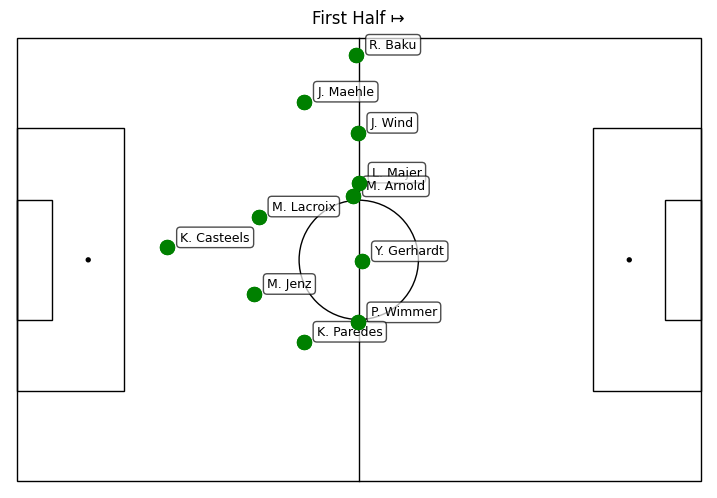

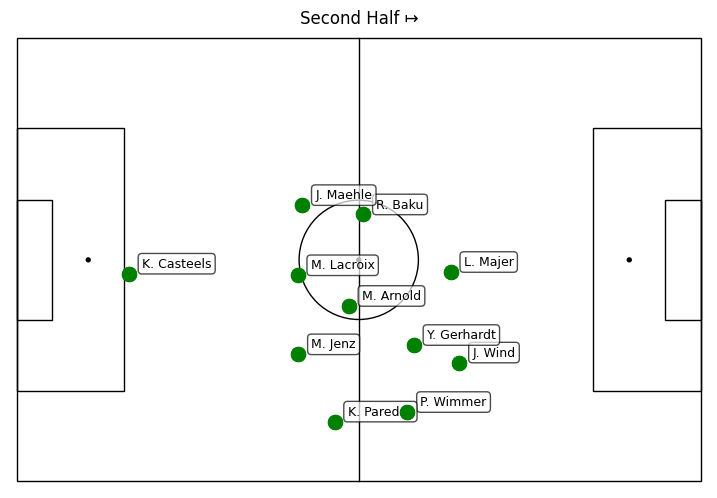

In [16]:
def plot_frame(df: pd.DataFrame, title="Tactical View", selected_team = home_team):
    team_frame = df[(df['team_code'] == selected_team)]
    """
    Draw all players in a specific frame over a realistic pitch.
    """
    ax = draw_soccer_pitch(figsize=(9, 6))
    ax.set_title(title)

    # Ball
    #ball = df[df["player_name"] == "BALL"]
    #ax.scatter(ball["x_position"], ball["y_position"], color="black", label="BALL", s=120, marker='o', zorder=5)

    # Players, colored by team
    team_codes = df["team_code"].dropna().unique()
    team_colors = plt.cm.get_cmap("tab10", len(team_codes))

    for i, team in enumerate(team_codes):
        team_df = df[(df["team_code"] == selected_team) ]#& (df["player_name"] != "BALL")]
        ax.scatter(team_df["x_position"], team_df["y_position"],
                   label=team,
                   s=100,
                   color= "Green", #team_colors(i),
                   zorder=4)

    # remove duplicate labels
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    #ax.legend(by_label.values(), by_label.keys(), loc="upper right")
    
    for _, row in team_frame.iterrows():
        x_pos = row['x_position']
        y_pos = row['y_position']
        ax.text(x_pos + 2, y_pos + 1, row['player_name'], fontsize=9, 
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))

    plt.show()

# Visually inspect the frames
plot_frame(flipped_df[flipped_df['frame'] == 1], title="First Half ↦", selected_team= home_team)
plot_frame(flipped_df[flipped_df['frame'] == 1250], title="Second Half ↦", selected_team = home_team)


#### 6. Normalization of Player Positions by Team and Frame

In [17]:
def normalize_team_positions_fast(df: pd.DataFrame, team_filter) -> pd.DataFrame:

    out = df.copy()

    # Restrict to the teams of interest (exclude ball, officials, etc.)
    out = out[out['team_code'].isin(team_filter)]

    # Per-group means and standard deviations (same shape via .transform)
    g = out.groupby(['frame', 'team_code'])
    out['x_mean'] = g['x_position'].transform('mean')
    out['y_mean'] = g['y_position'].transform('mean')
    out['x_std']  = g['x_position'].transform('std')
    out['y_std']  = g['y_position'].transform('std')

    # Prevent division by zero / NaN for groups with zero or single-value variance
    out['x_std'] = out['x_std'].replace(0, 1).fillna(1)
    out['y_std'] = out['y_std'].replace(0, 1).fillna(1)

    # Z-score normalization within each (frame, team)
    out['x_normalized'] = (out['x_position'] - out['x_mean']) / out['x_std']
    out['y_normalized'] = (out['y_position'] - out['y_mean']) / out['y_std']

    return out


# Build the team filter explicitly (avoids hidden globals)
team_filter = {home_team, away_team}

# Normalize players for the two teams; keep ball rows aside
normalized_df = normalize_team_positions_fast(flipped_df, team_filter=team_filter)

# Reattach ball rows unchanged (if present in the input)
ball_rows = flipped_df[flipped_df['team_code'] == 'BALL']
normalized_df = pd.concat([normalized_df, ball_rows], ignore_index=True)


In [18]:
# Plot a team's formation on a football pitch for a given frame.
def plot_normalized_formation_on_pitch(
    df,
    frame_number: int = 1,
    team_code: str = None,
    use_zscore: bool = True,
    annotate: bool = True,
    color: str = "green",
    ax: Optional[plt.Axes] = None,
    figsize: Tuple[int, int] = (9, 6),
):
    
    # Filter team and frame
    team_frame = df[(df["frame"] == frame_number) & (df["team_code"] == team_code)]
    if team_frame.empty:
        print(f"No data for frame {frame_number} and team {team_code}.")
        return None

    # Prepare axes and draw the pitch (meters)
    if ax is None:
        _, ax = plt.subplots(figsize=figsize)
    draw_soccer_pitch(ax=ax, scale=15)  # expects meter coordinates

    # Choose coordinates to plot
    if use_zscore:
        # Plot Z-scores directly (centered/standardized coordinates)
        x_plot = team_frame["x_normalized"]
        y_plot = team_frame["y_normalized"]
    else:
        # Reconstruct meter coordinates: x = z * std + mean
        required = {"x_mean", "y_mean", "x_std", "y_std"}
        missing = required - set(team_frame.columns)
        if missing:
            raise ValueError(f"Missing columns for reconstruction: {sorted(missing)}")
        x_plot = team_frame["x_normalized"] * team_frame["x_std"] + team_frame["x_mean"]
        y_plot = team_frame["y_normalized"] * team_frame["y_std"] + team_frame["y_mean"]

    # Scatter players
    ax.scatter(x_plot, y_plot, s=100, color=color, zorder=5)

    # Optional labels
    if annotate:
        # Small offset so labels don’t overlap points
        x_off, y_off = 0.14, 0.07  # meters
        for _, row in team_frame.iterrows():
            ax.text(
                (row["x_normalized"]  if use_zscore else row["x_normalized"] * row["x_std"] + row["x_mean"]) + x_off,
                (row["y_normalized"]  if use_zscore else row["y_normalized"] * row["y_std"] + row["y_mean"]) + y_off,
                row.get("player_name", ""),
                fontsize=9,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7),
                zorder=6,
            )

    ax.set_title(f"Formation — Frame {frame_number}, Team {team_code}", fontsize=14)
    plt.tight_layout()
    return


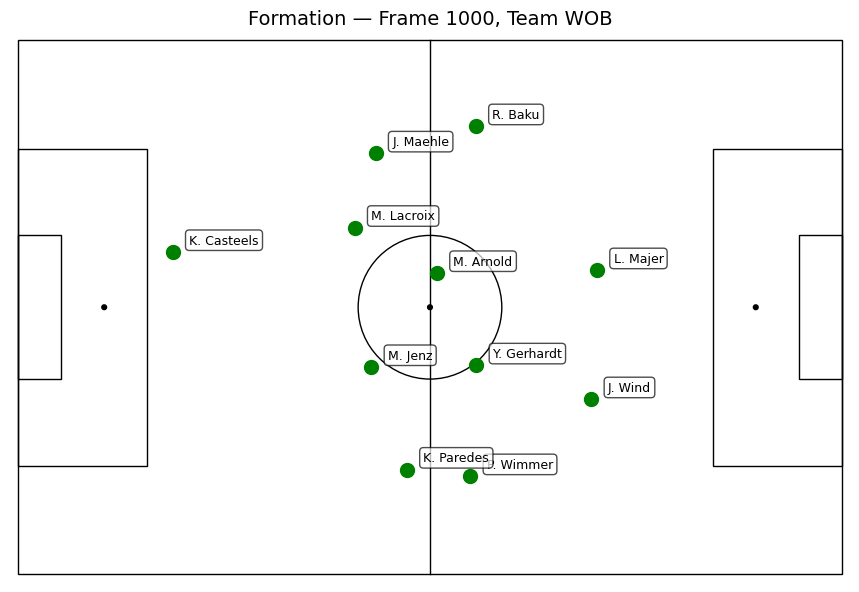

In [19]:
#Display the normalized formation on the pitch
plot_normalized_formation_on_pitch(normalized_df, frame_number= 1000, team_code = home_team)

#### 7. Compute team/player shape statistics from `normalized` coordinates in fixed windows

In [20]:
def compute_normalized_shapes_120s_with_breaks(
    df: pd.DataFrame,
    window_size_sec: int = 120,          # Target window length in seconds
    max_gap_sec: float = 3.0,           # If the time gap between consecutive rows exceeds this value, start a new window
    ts_col: str = "timestamp",
) -> pd.DataFrame:

    if df is None or df.empty:
        return pd.DataFrame()

    # Basic column check for normalization inputs
    required_norm = {"x_normalized", "y_normalized", ts_col}
    missing = required_norm - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    d = df.copy()

    # Convert timestamp to seconds (supports 'HH:MM:SS', datetime, or numeric seconds)
    ts = d[ts_col]
    if np.issubdtype(ts.dtype, np.number):
        d["time_sec"] = ts.astype(float)
    else:
        # Try datetime first; if it fails, fallback to 'to_timedelta'
        try:
            d["time_sec"] = pd.to_datetime(ts).astype("int64") / 1e9
        except Exception:
            d["time_sec"] = pd.to_timedelta(ts).dt.total_seconds()

    # Sort by time and compute inter-row gaps
    d = d.sort_values("time_sec").reset_index(drop=True)
    d["time_diff"] = d["time_sec"].diff().fillna(0.0)

    # Edge case: single-row input
    if len(d) == 1:
        return pd.DataFrame()

    chunks = []
    window_index = 0
    start_idx = 0
    start_time = float(d.loc[0, "time_sec"])

    # Iterate rows; end a window if it exceeds size or there is a long gap
    for i in range(1, len(d)):
        gap = float(d.loc[i, "time_diff"])
        current_time = float(d.loc[i, "time_sec"])
        elapsed = current_time - start_time

        if elapsed > window_size_sec or gap > max_gap_sec:
            window_df = d.iloc[start_idx:i]
            agg = process_window(window_df, window_index, start_time, float(d.loc[i - 1, "time_sec"]))
            if agg is not None:
                chunks.append(agg)
                window_index += 1

            # Start new window at current row
            start_idx = i
            start_time = current_time

    # Process the final window
    if start_idx < len(d):
        window_df = d.iloc[start_idx:]
        end_time = float(d.iloc[-1]["time_sec"])
        agg = process_window(window_df, window_index, start_time, end_time)
        if agg is not None:
            chunks.append(agg)

    return pd.concat(chunks, ignore_index=True) if chunks else pd.DataFrame()

# Helper: aggregate per-player statistics within a single window.
def process_window(
    window_df: pd.DataFrame,
    window_index: int,
    start_time: float,
    end_time: float,
) -> Optional[pd.DataFrame]:

    if window_df.empty:
        return None

    players_only = window_df[window_df["player_name"] != "BALL"]

    # Require at least 10 players in the window
    if players_only["player_name"].nunique() < 10:
        return None

    # Dominant ball possession (mode), fallback to "UNKNOWN"
    dom_pos = window_df["ball_possession"].dropna().mode()
    dominant_team = dom_pos.iloc[0] if not dom_pos.empty else "UNKNOWN"

    # Grouping keys (only include keys that exist)
    grouping_keys = [k for k in [
        "match_title",
        "team_code",
        "home_team_code",
        "away_team_code",
        "player_name",
        "game_section",
    ] if k in players_only.columns]

    # Aggregate normalized values (+ speed if available)
    agg_map = {
        "x_normalized": ["mean", "std"],
        "y_normalized": ["mean", "std"],
    }
    if "speed" in players_only.columns:
        agg_map["speed"] = ["mean"]

    grouped = players_only.groupby(grouping_keys).agg(agg_map)

    # Flatten MultiIndex columns and rename
    grouped.columns = [
        "_".join([c for c in col if c]) for col in grouped.columns.to_flat_index()
    ]
    rename_map = {
        "x_normalized_mean": "x_norm_mean",
        "x_normalized_std": "x_norm_std",
        "y_normalized_mean": "y_norm_mean",
        "y_normalized_std": "y_norm_std",
        "speed_mean": "speed_mean",
    }
    agg = grouped.rename(columns=rename_map).reset_index()

    # Add window metadata
    agg = agg.assign(
        window=window_index,
        dominant_possession=dominant_team,
        window_start_sec=start_time,
        window_end_sec=end_time,
        window_duration_sec=end_time - start_time,
    )

    return agg


In [21]:
# A new window starts whenever the time gap between rows exceeds 3 seconds.
df_window = compute_normalized_shapes_120s_with_breaks(
    normalized_df,
    window_size_sec=120,
    max_gap_sec=3
)

# Preview: first five rows for window 0 (empty if no such window exists).
df_window.loc[df_window["window"] == 0].head(5)


/tmp/ipykernel_3474/3323443059.py:26: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  d["time_sec"] = pd.to_datetime(ts).astype("int64") / 1e9


,match_title,team_code,home_team_code,away_team_code,player_name,game_section,x_norm_mean,x_norm_std,y_norm_mean,y_norm_std,speed_mean,window,dominant_possession,window_start_sec,window_end_sec,window_duration_sec
0,VfL Wolfsburg:SV Darmstadt 98,SVD,WOB,SVD,A. Brunst,firstHalf,-2.099854,0.196874,-0.105048,0.561709,6.139388,0,1.0,1.760400e+09,1.760400e+09,44.44
1,VfL Wolfsburg:SV Darmstadt 98,SVD,WOB,SVD,A. Müller,firstHalf,-0.075888,0.177637,0.117960,0.377517,10.613022,0,1.0,1.760400e+09,1.760400e+09,44.44
2,VfL Wolfsburg:SV Darmstadt 98,SVD,WOB,SVD,C. Klarer,firstHalf,-0.613232,0.111788,-0.145861,0.274334,9.470621,0,1.0,1.760400e+09,1.760400e+09,44.44
3,VfL Wolfsburg:SV Darmstadt 98,SVD,WOB,SVD,C. Zimmermann,firstHalf,-0.488312,0.152379,0.920704,0.238838,8.270674,0,1.0,1.760400e+09,1.760400e+09,44.44
4,VfL Wolfsburg:SV Darmstadt 98,SVD,WOB,SVD,E. Karic,firstHalf,-0.125018,0.316417,1.722004,0.260297,9.751241,0,1.0,1.760400e+09,1.760400e+09,44.44


In [22]:
# List of windows with duration < 5 sec
windows_to_drop = df_window.loc[df_window['window_duration_sec'] < 5 , 'window'].unique()

# 2. Drop all rows where window is in this list
df_window = df_window[~df_window['window'].isin(windows_to_drop)]

In [23]:
duration = df_window.value_counts('window_duration_sec')
duration.iloc[:5].sort_index

<bound method Series.sort_index of window_duration_sec
120.00    110
31.48      44
5.56       22
6.24       22
6.48       22
Name: count, dtype: int64>

#### 8. Numeric-like strings -> numbers (non-numeric -> NaN)


In [24]:
# Keeps the original column; writes a numeric clone for analysis.
df_window = df_window.copy()
df_window["dominant_possession_num"] = (
    pd.to_numeric(df_window["dominant_possession"], errors="coerce")
    .astype("Float64")  # Pandas nullable float
)

print(df_window["dominant_possession_num"].unique())
print(df_window["dominant_possession_num"].dtype)


<FloatingArray>
[1.0, 2.0]
Length: 2, dtype: Float64
Float64


#### 9. In- and Out-of-Possession labeling

In [25]:
def add_possession_role_column(
    df: pd.DataFrame,
    pos_col: str = "dominant_possession",
    team_col: str = "team_code",
    home_col: str = "home_team_code",
    away_col: str = "away_team_code",
    out_col: str = "dominant_possession_team",
    unknown_label: str = "Out_of_possession",
) -> pd.DataFrame:

    required = {pos_col, team_col, home_col, away_col}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    out = df.copy()

    # Coerce possession to numeric; non-numeric -> NaN (treated as not in possession)
    pos = pd.to_numeric(out[pos_col], errors="coerce")

    # Vectorized conditions
    home_in_pos = (pos == 1) & (out[team_col] == out[home_col])
    away_in_pos = (pos == 2) & (out[team_col] == out[away_col])

    # Assign labels
    out[out_col] = np.where(home_in_pos | away_in_pos, "In_possession", unknown_label)

    # Use a compact, explicit categorical dtype
    out[out_col] = pd.Categorical(out[out_col], categories=["In_possession", unknown_label], ordered=False)

    return out

In [26]:
df_window = add_possession_role_column(df_window)
df_window.head(22)


,match_title,team_code,home_team_code,away_team_code,player_name,game_section,x_norm_mean,x_norm_std,y_norm_mean,y_norm_std,speed_mean,window,dominant_possession,window_start_sec,window_end_sec,window_duration_sec,dominant_possession_num,dominant_possession_team
0,VfL Wolfsburg:SV Darmstadt 98,SVD,WOB,SVD,A. Brunst,firstHalf,-2.099854,0.196874,-0.105048,0.561709,6.139388,0,1.0,1.760400e+09,1.760400e+09,44.44,1.0,Out_of_possession
1,VfL Wolfsburg:SV Darmstadt 98,SVD,WOB,SVD,A. Müller,firstHalf,-0.075888,0.177637,0.117960,0.377517,10.613022,0,1.0,1.760400e+09,1.760400e+09,44.44,1.0,Out_of_possession
2,VfL Wolfsburg:SV Darmstadt 98,SVD,WOB,SVD,C. Klarer,firstHalf,-0.613232,0.111788,-0.145861,0.274334,9.470621,0,1.0,1.760400e+09,1.760400e+09,44.44,1.0,Out_of_possession
3,VfL Wolfsburg:SV Darmstadt 98,SVD,WOB,SVD,C. Zimmermann,firstHalf,-0.488312,0.152379,0.920704,0.238838,8.270674,0,1.0,1.760400e+09,1.760400e+09,44.44,1.0,Out_of_possession
4,VfL Wolfsburg:SV Darmstadt 98,SVD,WOB,SVD,E. Karic,firstHalf,-0.125018,0.316417,1.722004,0.260297,9.751241,0,1.0,1.760400e+09,1.760400e+09,44.44,1.0,Out_of_possession
5,VfL Wolfsburg:SV Darmstadt 98,SVD,WOB,SVD,F. Nürnberger,firstHalf,0.141117,0.291699,-1.702051,0.399483,9.771313,0,1.0,1.760400e+09,1.760400e+09,44.44,1.0,Out_of_possession
6,VfL Wolfsburg:SV Darmstadt 98,SVD,WOB,SVD,J. Justvan,firstHalf,0.502394,0.226086,-0.371358,0.180021,8.975629,0,1.0,1.760400e+09,1.760400e+09,44.44,1.0,Out_of_possession
7,VfL Wolfsburg:SV Darmstadt 98,SVD,WOB,SVD,M. Maglica,firstHalf,-0.428058,0.094172,-0.970756,0.293771,8.699433,0,1.0,1.760400e+09,1.760400e+09,44.44,1.0,Out_of_possession
8,VfL Wolfsburg:SV Darmstadt 98,SVD,WOB,SVD,M. Mehlem,firstHalf,0.519624,0.332477,0.432797,0.255687,12.006367,0,1.0,1.760400e+09,1.760400e+09,44.44,1.0,Out_of_possession
9,VfL Wolfsburg:SV Darmstadt 98,SVD,WOB,SVD,O. Vilhelmsson,firstHalf,1.373061,0.362350,-0.559995,0.352965,12.412167,0,1.0,1.760400e+09,1.760400e+09,44.44,1.0,Out_of_possession


In [27]:
# Plot a team's formation and ellipses for a window.
def plot_normalized_team_formation_and_shape_on_pitch(
    df_window_no_gk: pd.DataFrame,
    team_code: str,
    title: str = "Normalized Team Formation & Shape",
    save_path: str | None = None,
    point_color: str = "green",
    show_ellipses: bool = True,
    label: bool = True,
):

    # Subset this team
    team_df = df_window_no_gk[df_window_no_gk["team_code"] == team_code].copy()
    if team_df.empty:
        print(f"No data for team {team_code} in this window.")
        return None

    # Figure & pitch (match the previous look with a larger figure)
    fig, ax = plt.subplots(figsize=(9, 6))
    try:
        # If your pitch helper supports 'scale' (meters/scale -> z-score-friendly extents)
        draw_soccer_pitch(ax=ax, scale=15)
    except TypeError:
        # Fallback for pitch helper without 'scale'
        draw_soccer_pitch(ax=ax)

    # Optional context for title
    win = team_df["window"].iloc[0] if "window" in team_df.columns else None
    dom = team_df.get("dominant_possession_team", pd.Series(["unknown"])).iloc[0]
    dur = team_df.get("window_duration_sec", pd.Series([pd.NA])).iloc[0]
    if pd.notna(dur):
        dur_fmt = f"{float(dur):.2f}".rstrip("0").rstrip(".")
    else:
        dur_fmt = "unknown"

    # Scatter mean positions (normalized coordinates)
    ax.scatter(
        team_df["x_norm_mean"],
        team_df["y_norm_mean"],
        s=100,
        color=point_color,
        zorder=5,
    )

    # 1σ ellipses (light grey, behind points)
    if show_ellipses:
        for _, r in team_df.iterrows():
            e = Ellipse(
                (r["x_norm_mean"], r["y_norm_mean"]),
                width=2 * r["x_norm_std"],
                height=2 * r["y_norm_std"],
                facecolor="grey",
                edgecolor="grey",
                alpha=0.2,
                zorder=4,
            )
            ax.add_patch(e)

    # Player name labels (white rounded box, slight offset like before)
    if label and "player_name" in team_df.columns:
        x_off, y_off = 0.14, 0.07  # meters
        for _, r in team_df.iterrows():
            ax.text(
                r["x_norm_mean"] + x_off,
                r["y_norm_mean"] + y_off,
                str(r["player_name"]),
                fontsize=9,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7),
                zorder=6,
            )

    # Title formatted similar to the prior plot
    title_parts = []
    if win is not None:
        title_parts.append(f"Window {win}")
    title_parts.append(str(dom))
    title_parts.append(f"duration: {dur_fmt} s")
    ax.set_title(f"{title} — " + " — ".join(title_parts), fontsize=14)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
        plt.close(fig)
        return None
    else:
        plt.show()
        return


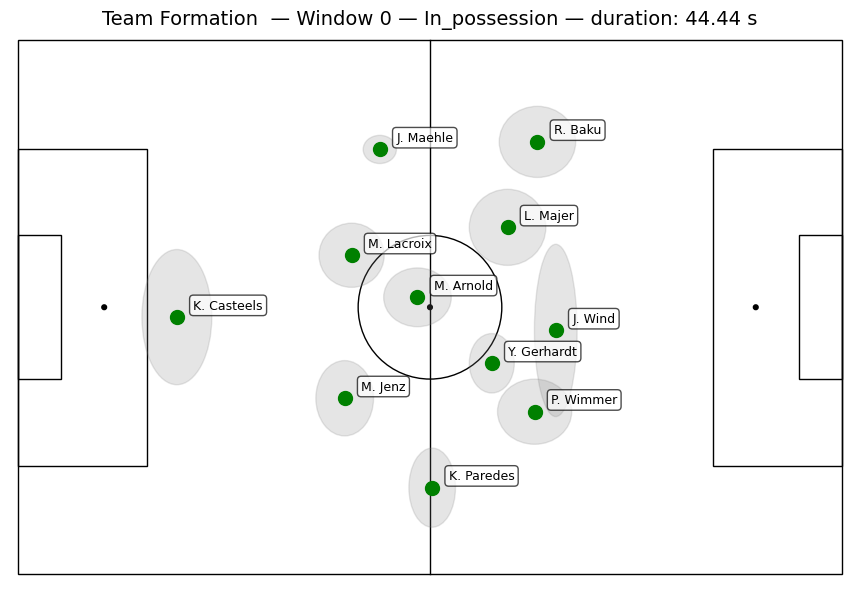

In [28]:
# Plot team shape with ellipses for the first window
team_shapes_window = df_window[df_window['window'] == 0]  # Filter for the first window
plot_normalized_team_formation_and_shape_on_pitch(team_shapes_window, team_code= home_team,
                                                  title="Team Formation ", save_path=None)
# plot_normalized_team_formation_and_shape_on_pitch(team_shapes_window, team_code= away_team,
#                                                   title="Team Formation ", save_path=None)

#### 10. Remove goalkeeper

In [46]:
def remove_goalkeepers(df_window: pd.DataFrame) -> pd.DataFrame:

    result_rows = []

    for (window_id, team_code), group in df_window.groupby(["window", "team_code"]):
        # Goalkeeper = player with minimal x_norm_mean in this group
        gk_row = group.loc[group["x_norm_mean"].idxmin()]

        # Keep all players except the identified goalkeeper
        filtered = group[group["player_name"] != gk_row["player_name"]]
        result_rows.append(filtered)

    # Concatenate all groups back together
    return pd.concat(result_rows, ignore_index=True)

df_window_no_gk = remove_goalkeepers(df_window)

In [47]:
df_window_no_gk['window'].unique()

array([  0,   1,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  17,  18,  19,  20,  21,  22,  23,  24,  25,  27,  28,
        29,  30,  31,  32,  33,  35,  36,  37,  38,  41,  42,  43,  45,
        46,  48,  49,  51,  52,  53,  54,  55,  56,  57,  58,  59,  60,
        61,  63,  64,  66,  68,  69,  71,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  85,  86,  87,  88,  89,  90,  91,  94,
        96,  97,  98,  99, 100, 101])

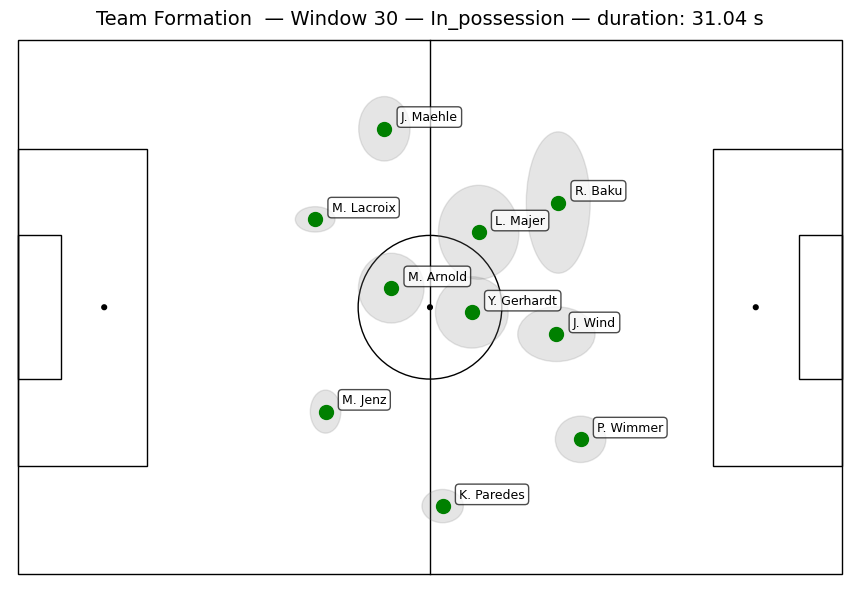

In [48]:
team_shapes_window = df_window_no_gk[df_window_no_gk['window'] == 30 ]  # Filter for the first window
plot_normalized_team_formation_and_shape_on_pitch(team_shapes_window, team_code= home_team, title="Team Formation ")
# plot_normalized_team_formation_and_shape_on_pitch(team_shapes_window, team_code= away_team, title="Team Formation ")

### 11. Team Window Grouping and Validation

In [51]:
# Team-based window grouping (each group = 10 players)
group_cols = ["match_title", "game_section", "window", "team_code"]

# Create a continuous global ID based on occurrence order (0..N-1)
df_window_no_gk["window_global"] = df_window_no_gk.groupby(group_cols, sort=False).ngroup()

# Identify window_global groups that do not contain exactly 10 rows (i.e., invalid teams)
invalid_windows = df_window_no_gk["window_global"].value_counts()
invalid_windows = invalid_windows[invalid_windows != 10]
print(f"Invalid windows shape: {invalid_windows.shape}")

# Remove all invalid windows from the dataset
df = df_window_no_gk[~df_window_no_gk["window_global"].isin(invalid_windows.index)].copy()
print(f"Number of rows after removing invalid windows: {len(df)}")

# Reassign continuous window_global IDs after cleaning
df["window_global"] = df.groupby(group_cols, sort=False).ngroup()

# Preview the first rows
df.head()


Invalid windows shape: (0,)
Number of rows after removing invalid windows: 1680


,match_title,team_code,home_team_code,away_team_code,player_name,game_section,x_norm_mean,x_norm_std,y_norm_mean,y_norm_std,speed_mean,window,dominant_possession,window_start_sec,window_end_sec,window_duration_sec,dominant_possession_num,dominant_possession_team,window_global
0,VfL Wolfsburg:SV Darmstadt 98,SVD,WOB,SVD,A. Müller,firstHalf,-0.075888,0.177637,0.117960,0.377517,10.613022,0,1.0,1.760400e+09,1.760400e+09,44.44,1.0,Out_of_possession,0
1,VfL Wolfsburg:SV Darmstadt 98,SVD,WOB,SVD,C. Klarer,firstHalf,-0.613232,0.111788,-0.145861,0.274334,9.470621,0,1.0,1.760400e+09,1.760400e+09,44.44,1.0,Out_of_possession,0
2,VfL Wolfsburg:SV Darmstadt 98,SVD,WOB,SVD,C. Zimmermann,firstHalf,-0.488312,0.152379,0.920704,0.238838,8.270674,0,1.0,1.760400e+09,1.760400e+09,44.44,1.0,Out_of_possession,0
3,VfL Wolfsburg:SV Darmstadt 98,SVD,WOB,SVD,E. Karic,firstHalf,-0.125018,0.316417,1.722004,0.260297,9.751241,0,1.0,1.760400e+09,1.760400e+09,44.44,1.0,Out_of_possession,0
4,VfL Wolfsburg:SV Darmstadt 98,SVD,WOB,SVD,F. Nürnberger,firstHalf,0.141117,0.291699,-1.702051,0.399483,9.771313,0,1.0,1.760400e+09,1.760400e+09,44.44,1.0,Out_of_possession,0


### 12. Building Team-Level Feature Aggregates per Tactical Window

In [50]:
def build_df_new_features_all_teams(df: pd.DataFrame) -> pd.DataFrame:

    # Validate required columns
    required_cols = {"team_code", "window_global", "dominant_possession_team"}
    if not required_cols <= set(df.columns):
        missing = required_cols - set(df.columns)
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    rows = []

    # ---- Group data by team, possession state, and time window ----
    for (team_code, pos_state, w), dfw in df.groupby(
        ["team_code", "dominant_possession_team", "window_global"], sort=True
    ):
        if dfw.empty:
            continue

        # Compute spatial & statistical aggregates for this team-window
        feats = _compute_rf_aggregates_for_window(dfw)

        # Get contextual info from the first row of the group
        first = dfw.iloc[0]
        row = {
            "team_code": team_code,
            "possession_state": pos_state,  # "In_possession" or "Out_of_possession"
            "window_global": w,
            "game_section": first.get("game_section", np.nan),
        }
        row.update(feats)
        rows.append(row)

    # ---- Safety check: ensure we produced some valid rows ----
    if not rows:
        counts = (
            df.groupby(["team_code", "dominant_possession_team", "window_global"])
            .size()
            .rename("n")
            .reset_index()
        )
        print("Debug counts per (team, state, window):")
        print(counts.head(20).to_string(index=False))
        raise ValueError("No valid (team, state, window) groups produced any rows.")

    # Sorted ONLY by global window index for chronological order
    df_new = pd.DataFrame(rows).sort_values("window_global").reset_index(drop=True)
    return df_new

df_features = build_df_new_features_all_teams(df)
df_features.head()


/tmp/ipykernel_3474/3078005218.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for (team_code, pos_state, w), dfw in df.groupby(


,team_code,possession_state,window_global,game_section,centroid_x,centroid_y,width,length,area,ratio,dist_mean,dist_std,x_norm_std_mean,y_norm_std_mean,speed_mean_team
0,SVD,Out_of_possession,0,firstHalf,0.209985,0.010505,1.986293,3.424055,6.801177,0.580100,1.048365,0.474651,0.234167,0.294859,10.245883
1,WOB,In_possession,1,firstHalf,0.214964,0.008382,1.792474,2.936433,5.263479,0.610425,1.050134,0.396297,0.248530,0.318388,10.774210
2,SVD,In_possession,2,firstHalf,0.173987,0.020080,2.292927,3.058085,7.011965,0.749792,1.165090,0.414358,0.249165,0.208730,9.680914
3,WOB,Out_of_possession,3,firstHalf,0.234570,0.019866,1.626806,2.808926,4.569576,0.579156,1.054897,0.349412,0.232210,0.219427,9.911860
4,SVD,Out_of_possession,4,firstHalf,0.181819,0.024495,2.190451,2.898538,6.349105,0.755709,1.014792,0.434630,0.287415,0.455480,10.147213


# Save to CSV

In [52]:
df.to_csv(f'tracking_raw_cleaned_{match_id}.csv', index=False)

In [53]:
df_features.to_csv(f'tracking_features_{match_id}.csv', index=False)